# 04 — Treino do Classificador de Ataques e do Seletor de Defesa

Treina `RLAttackClassifier` (classificação supervisionada dos 4 scores de detecção -> tipo de ataque) e `RLDefenseSelector` (RL genuíno: reward vindo de rodadas reais de FL) — ver Fase 2/3 e a nota de design em `src/classification/rl_classifier.py` sobre por que só o seletor é RL de fato.

In [1]:
import sys, os
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from src.classification.rl_classifier import RLAttackClassifier
from src.defense.rl_selector import RLDefenseSelector
from src.utils.data_loader import (
    generate_detection_dataset, generate_selector_experiences, load_dataset_participants)

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)

DATASET, SPLIT, N_CLIENTS, N_CLASSES = 'mnist', 'non_iid', 10, 10
ATTACK_TYPES = ['sign_flipping', 'gaussian_noise', 'label_flipping']
ATTACK_LABELS = ['none'] + ATTACK_TYPES
participants, root_data = load_dataset_participants(DATASET, SPLIT, N_CLIENTS, data_root='../data/processed')

I0000 00:00:1785807411.696871 1116798 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785807411.697354 1116798 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785807411.726824 1116798 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785807412.630737 1116798 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785807412.631066 1116798 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
X, _y_bin, y_attack_type = generate_detection_dataset(
    participants, n_rounds=12, attack_types=ATTACK_TYPES,
    byzantine_fraction=0.3, aggregation='fedavg', n_classes=N_CLASSES, seed=1)
label_to_idx = {label: i for i, label in enumerate(ATTACK_LABELS)}
y_idx = [label_to_idx[t] for t in y_attack_type]

classifier = RLAttackClassifier(n_attacks=len(ATTACK_LABELS))
clf_losses = classifier.train(X, y_idx, epochs=40, batch_size=32, verbose=False)
classifier.save('../results/models/rl_classifier.weights.h5')
print(f'Classifier loss: {clf_losses[0]:.4f} -> {clf_losses[-1]:.4f}')

E0000 00:00:1785807448.846171 1116798 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1785807448.865500 1116798 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Classifier loss: 1.3958 -> 0.2353


In [3]:
selector = RLDefenseSelector()
experiences = generate_selector_experiences(
    participants, selector.actions, attack_types=ATTACK_LABELS,
    n_rounds=8, byzantine_fraction=0.3, n_classes=N_CLASSES, seed=1)
sel_losses = selector.train_on_experiences(experiences, verbose=False)
selector.save('../results/models/rl_selector.weights.h5')
print(f'{len(experiences)} experiências | loss média={sum(sel_losses)/len(sel_losses):.4f}')
for (state, action_idx, reward, _next_state) in experiences:
    attack_name = ATTACK_LABELS[int(state[0])]
    print(f'  {attack_name:15s} -> {selector.actions[action_idx]:14s} reward={reward:+.2f}')

28 experiências | loss média=0.7382
  none            -> fedavg         reward=+1.00
  none            -> fedprox        reward=+1.00
  none            -> median         reward=+1.00
  none            -> trimmed_mean   reward=+1.00
  none            -> fltrust        reward=-0.60
  none            -> clustering     reward=+1.00
  none            -> krum           reward=-0.60
  sign_flipping   -> fedavg         reward=-0.50
  sign_flipping   -> fedprox        reward=-0.50
  sign_flipping   -> median         reward=-0.50
  sign_flipping   -> trimmed_mean   reward=-0.50
  sign_flipping   -> fltrust        reward=-0.50
  sign_flipping   -> clustering     reward=-0.50
  sign_flipping   -> krum           reward=-0.50
  gaussian_noise  -> fedavg         reward=-0.50
  gaussian_noise  -> fedprox        reward=-0.50
  gaussian_noise  -> median         reward=+1.50
  gaussian_noise  -> trimmed_mean   reward=-0.50
  gaussian_noise  -> fltrust        reward=-0.50
  gaussian_noise  -> clustering  

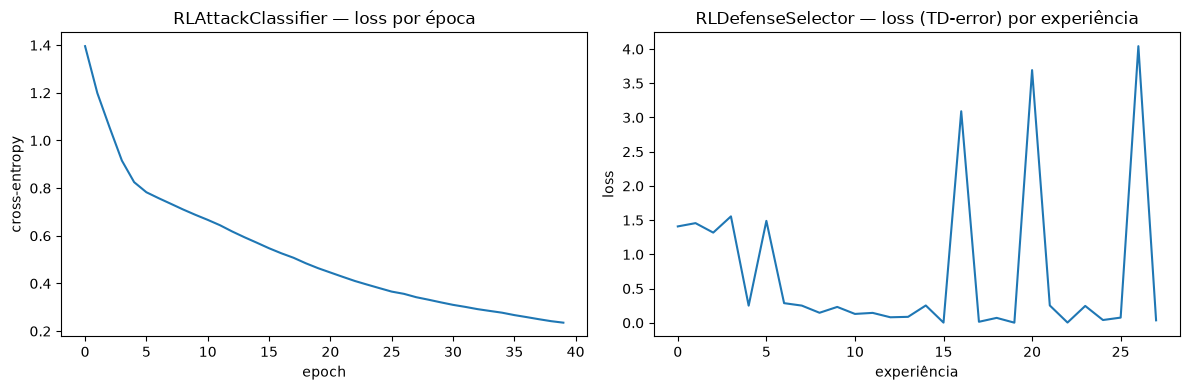

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(clf_losses); axes[0].set_title('RLAttackClassifier — loss por época')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy')
axes[1].plot(sel_losses); axes[1].set_title('RLDefenseSelector — loss (TD-error) por experiência')
axes[1].set_xlabel('experiência'); axes[1].set_ylabel('loss')
plt.tight_layout()
plt.savefig('../results/figures/04_rl_training_curves.png', bbox_inches='tight')
plt.show()